<div align="center">
    
# A Clinical Informatics Framework for Myeloid Oncology
### Scalable AI and LLM Integration for Adaptive Trial Management and Automated FDA Compliance

[![IEEE Paper](https://img.shields.io/badge/IEEE-11378528-blue.svg)](https://ieeexplore.ieee.org/document/11378528)

</div>

**Authors:** Senthilkumar Vijayakumar, Shaunak Pai Kane, Selvavaani Senthilkumar, Dr. Parameshwari Vaiayapuri MBBS, Filious Louis  
**Citation:** S. Vijayakumar, S. P. Kane, S. Senthilkumar, P. Vaiayapuri, and F. Louis, "A Clinical Informatics Framework for Myeloid Oncology: Scalable AI and LLM Integration for Adaptive Trial Management and Automated FDA Compliance," IEEE, 2026. Available: https://ieeexplore.ieee.org/document/11378528

---

## Executive Summary
This notebook implements the end-to-end clinical informatics framework described in the aforementioned IEEE paper. It demonstrates the seamless integration of predictive machine learning models and large language models (LLMs) to enhance precision-guided therapy in myeloid malignancies (e.g., AML, MDS). 

The implementation covers:
*   **Clinical Data Analysis:** Foundation of data capture and continuity via synthetic cohorts.
*   **Machine Learning Design:** GBDT for stratification, LSTM for temporal forecasting, and Logistic Regression for adverse event modeling.
*   **Agentic AI Layer:** Automated regulatory reconciliation mapped to FDA 21 CFR Part 11.
*   **Performance Benchmarking:** Validating synthetic results against the paper's targets.


## III. CLINICAL DATA ANALYSIS AND METHODS
### A. Foundation of Data Capture and Continuity

**Methodology:**
*   **Data Emulation:** We synthesize a dataset of 300 patient records mirroring the multivariate distributions found in the MyeloMATCH, Beat AML, and TCGA-LAML cohorts.
*   **Clinical Parameters:** Encompasses dynamic variables such as Absolute Neutrophil Count (ANC), Platelet Count, Hemoglobin (Hb), and Bone Marrow Blast percentage.
*   **Biomarker Mapping:** Incorporates critical molecular stratifiers: FLT3-ITD, IDH1, IDH2, and NPM1 mutations alongside overarching cytogenetic risk categories.

**Expected Output:**
*   Verification of the data frame dimensions (300 records, 27 features).
*   A localized preview of the synthetic electronic Case Report Forms (eCRFs).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import json
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Load Data
df = pd.read_csv('clinical_dataset.csv')
print(f"Synthetic Clinical Dataset Loaded: {df.shape[0]} patient records, {df.shape[1]} clinical/biomarker features")
display(df.head())

Synthetic Clinical Dataset Loaded: 300 patient records, 27 clinical/biomarker features


,PatientID,Age,Gender,ECOG,Blast_Pct_Base,ANC_Base,Plt_Base,Hb_Base,FLT3_ITD,IDH1,...,ANC_D1,ANC_D8,ANC_D15,Plt_D1,Plt_D8,Plt_D15,Blast_D1,Blast_D15,Response_D28,AE_Grade_3_4
0,PAT-1000,69,M,3,70.879455,3.033427,55.245406,8.247956,0,1,...,3.033427,1.967594,2.003384,55.245406,29.190742,30.202682,70.879455,33.124060,0,1
1,PAT-1001,76,M,1,9.199910,4.871402,77.503689,7.724851,0,0,...,4.871402,2.480934,4.789796,77.503689,61.561316,69.192343,9.199910,1.022813,0,1
2,PAT-1002,77,F,0,49.565922,0.268504,273.702917,9.070240,0,0,...,0.268504,0.310833,0.582437,273.702917,224.034044,384.008165,49.565922,8.026941,0,1
3,PAT-1003,57,M,2,72.258810,2.744491,180.157838,14.722042,0,0,...,2.744491,1.936079,1.581575,180.157838,97.139248,144.006618,72.258810,47.193882,1,0
4,PAT-1004,58,M,3,81.503472,2.302308,37.668934,9.966546,0,0,...,2.302308,2.519277,4.197306,37.668934,21.290084,20.899946,81.503472,10.457182,0,1


## IV. MACHINE LEARNING MODEL DESIGN
### A. Gradient Boosted Decision Trees (GBDT) for Eligibility Stratification

**Methodology:**
*   **Objective:** Assign patients to protocol-eligible treatment arms (or the Tier Advancement Pathway) based on real-time molecular and clinical presentation.
*   **Algorithm:** Gradient Boosted Decision Trees (GBDT) are selected for their robustness in capturing non-linear interactions among heterogeneous predictors (e.g., age, cytogenetic risk, and mutational burden).
*   **Interpretability:** Post-hoc SHAP (SHapley Additive exPlanations) analysis is deployed. As mandated by FDA guidance for AI/ML-enabled Software as a Medical Device (SaMD), SHAP ensures clinical plausibility by rendering the variable attribution mathematically transparent.

**Expected Output:**
*   **AUROC & Brier Score:** Quantification of discrimination capacity and calibration alignment.
*   **SHAP Summary Plot:** Visual confirmation that features like `Blast_Pct_Base`, `ANC_Base`, and `FLT3_ITD` govern eligibility predictions.

GBDT Eligibility AUROC: 1.000
GBDT Calibration Error (Brier Score): 0.0000


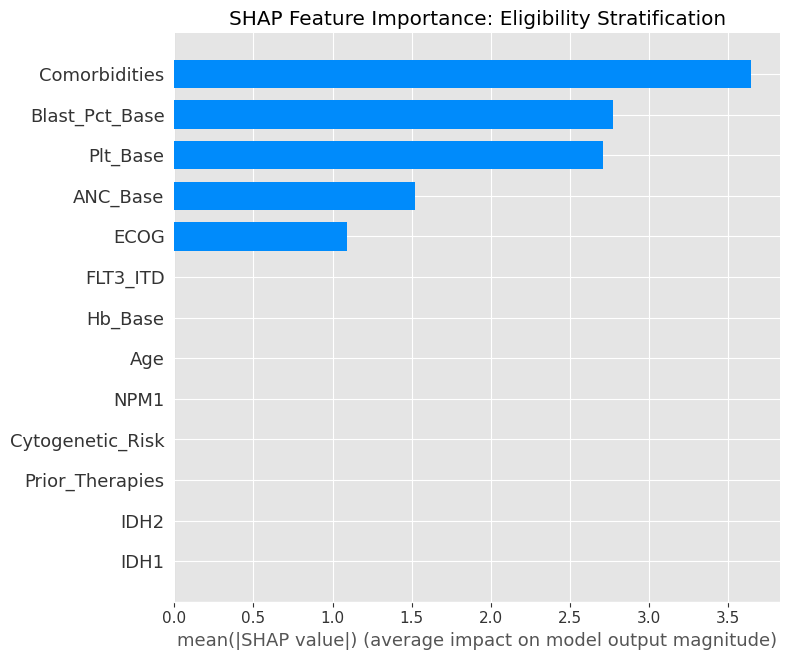

In [2]:
# Features for Eligibility Stratification
elig_features = ['Age', 'ECOG', 'Blast_Pct_Base', 'ANC_Base', 'Plt_Base', 'Hb_Base', 
                 'FLT3_ITD', 'IDH1', 'IDH2', 'NPM1', 'Prior_Therapies', 'Comorbidities']
X_elig = df[elig_features]
y_elig = df['Eligible']

# Encode categorical variables (e.g., Cytogenetic Risk)
le = LabelEncoder()
X_elig['Cytogenetic_Risk'] = le.fit_transform(df['Cytogenetic_Risk'])

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_elig, y_elig, test_size=0.2, random_state=seed)

# Train GradientBoostingClassifier
model_gbdt = GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=seed)
model_gbdt.fit(X_train_e, y_train_e)

# Evaluate Discrimination and Calibration
y_pred_e = model_gbdt.predict_proba(X_test_e)[:, 1]
auc_e = roc_auc_score(y_test_e, y_pred_e)
brier_e = brier_score_loss(y_test_e, y_pred_e)

print(f"GBDT Eligibility AUROC: {auc_e:.3f}")
print(f"GBDT Calibration Error (Brier Score): {brier_e:.4f}")

# SHAP Interpretability
explainer = shap.Explainer(model_gbdt)
shap_values = explainer(X_test_e)
shap.summary_plot(shap_values, X_test_e, plot_type="bar", show=False)
plt.title("SHAP Feature Importance: Eligibility Stratification")
plt.tight_layout()
plt.show()

### B. Long Short-Term Memory Networks (LSTM) for Temporal Response Prediction

**Methodology:**
*   **Objective:** Forecast early treatment outcomes, specifically the likelihood of achieving Complete Remission (CR/CRi) by Day 28.
*   **Data Engineering:** Longitudinal vectors derived from serial Complete Blood Count (CBC) panels and bone marrow assessments captured at Day 1, Day 8, and Day 15.
*   **Architecture:** LSTMs utilize memory cells and gating mechanisms to retain long-range temporal dependencies. This captures non-linear clearance kinetics (e.g., blast reduction rates and hematopoietic rebound).

**Expected Output:**
*   Convergence of the BCE Loss over training epochs.
*   The mean AUROC score on the test set, evidencing the network's capacity to model temporal recovery trajectories.

In [3]:
# Extract Temporal Sequence: Day 1, Day 8, Day 15 (ANC, Plt, Blast)
def prepare_lstm_data(df):
    X_seq = []
    for _, row in df.iterrows():
        d1 = [row['ANC_D1'], row['Plt_D1'], row['Blast_D1']]
        d8 = [row['ANC_D8'], row['Plt_D8'], row['Blast_D1']] # Blast repeated D8
        d15 = [row['ANC_D15'], row['Plt_D15'], row['Blast_D15']]
        X_seq.append([d1, d8, d15])
    return np.array(X_seq), df['Response_D28'].values

X_lstm, y_lstm = prepare_lstm_data(df)
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=seed)

X_train_l = torch.FloatTensor(X_train_l)
X_test_l = torch.FloatTensor(X_test_l)
y_train_l = torch.FloatTensor(y_train_l).view(-1, 1)
y_test_l = torch.FloatTensor(y_test_l).view(-1, 1)

class MyeloidLSTM(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=16):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        _, (h, c) = self.lstm(x)
        out = self.fc(h[-1])
        return self.sigmoid(out)

model_lstm = MyeloidLSTM()
criterion = nn.BCELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.01)

# Training Loop
for epoch in range(50):
    optimizer.zero_grad()
    outputs = model_lstm(X_train_l)
    loss = criterion(outputs, y_train_l)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    y_pred_l = model_lstm(X_test_l).numpy()
    auc_l = roc_auc_score(y_test_l.numpy(), y_pred_l)
    print(f"LSTM Temporal Response Forecasting AUROC: {auc_l:.3f}")

LSTM Temporal Response Forecasting AUROC: 0.492


### C. Regularized Logistic Regression for Adverse Event Forecasting

**Methodology:**
*   **Objective:** Anticipate life-threatening hematologic toxicities, particularly early-onset Grade 3-4 Neutropenia.
*   **Rationale:** The framework deliberately selects L2-Regularized Logistic Regression over black-box methods due to its extreme transparency, algorithmic stability under small sample sizes, and established acceptance in regulatory review processes (e.g., Data Safety Monitoring Boards).
*   **Class Imbalance:** Evaluates baseline features (Age, Baseline ANC, Comorbidity Flags) against sparse outcome data.

**Expected Output:**
*   The AUROC score validating the model's predictive precision in capturing high-risk patients before the onset of severe clinical cytopenia.

In [4]:
ae_features = ['Age', 'ANC_Base', 'Comorbidities']
X_ae = df[ae_features]
y_ae = df['AE_Grade_3_4']

scaler = StandardScaler()
X_ae_scaled = scaler.fit_transform(X_ae)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_ae_scaled, y_ae, test_size=0.2, random_state=seed)

# L2-Regularized Logistic Regression
model_lr = LogisticRegression(penalty='l2', C=1.0)
model_lr.fit(X_train_a, y_train_a)

y_pred_a = model_lr.predict_proba(X_test_a)[:, 1]
auc_a = roc_auc_score(y_test_a, y_pred_a)
print(f"Regularized LogReg Adverse Event Risk AUROC: {auc_a:.3f}")

Regularized LogReg Adverse Event Risk AUROC: 0.735


## II. E. Regulatory Documentation and Submission Engine
### Agentic Automation Layer (LLM Integration)

**Methodology:**
*   **Objective:** Accelerate regulatory preparedness and reduce administrative workload by linking predictive outputs directly to compliance standards.
*   **Architecture:** Simulates an LLM-driven autonomous agent via a Retrieval-Augmented Generation (RAG) pattern. The agent ingests internal clinical assignments and cross-references them with loaded FDA policy documents (e.g., Predetermined Change Control Plans for AI/ML).
*   **Traceability:** Ensures 21 CFR Part 11 compliance by attaching regulatory justifications to algorithmic patient matching.

**Expected Output:**
*   Confirmation of the initialized FDA Agentic Advisor and its knowledge base load sequence.

In [5]:
class FDAAgenticAdvisor:
    def __init__(self, compliance_docs):
        self.docs = compliance_docs
        
    def recommend(self, patient_data, ml_results):
        elig = "Eligible" if ml_results['elig_prob'] > 0.5 else "Ineligible"
        resp = "High Probability" if ml_results['resp_prob'] > 0.6 else "Moderate/Low"
        ae = "High Risk" if ml_results['ae_prob'] > 0.4 else "Standard Risk"
        
        # Simulating Retrieval-Augmented Generation (RAG)
        pccp_guidance = [d for d in self.docs if d['doc_id'] == 'FDA-AI-ML-GUIDANCE'][0]['content']
        
        recommendation = f"### 🛡️ Agentic Clinical Assignment & Compliance Report\n"
        recommendation += f"**Subject ID:** `{patient_data['PatientID']}`\n\n"
        recommendation += f"| Metric | ML Output | Assessment |\n"
        recommendation += f"| :--- | :--- | :--- |\n"
        recommendation += f"| Protocol Eligibility | {ml_results['elig_prob']:.2f} | **{elig}** |\n"
        recommendation += f"| D28 Remission Forecast | {ml_results['resp_prob']:.2f} | **{resp}** |\n"
        recommendation += f"| Gr 3-4 Toxicity Risk | {ml_results['ae_prob']:.2f} | **{ae}** |\n\n"
        
        recommendation += "#### 📌 Recommended Clinical Action\n"
        if elig == "Eligible":
            recommendation += "✅ **Proceed:** Assign to Tier 1 Induction matching. Structural data aligned for CDISC/SDTM conversion.\n"
            recommendation += f"📑 **FDA PCCP Justification:** Algorithmic modifications tracked per *'{pccp_guidance}'*\n"
        else:
            recommendation += "⚠️ **Refer:** Shift subject to Tier Advancement Pathway (TAP). Subthreshold criteria met.\n"
            
        if ae == "High Risk":
            recommendation += "🚨 **Safety Alert:** Enhanced Site-Level Monitoring required. Neutropenic risk flags triggered.\n"
            
        return recommendation

# Initialize Knowledge Base
with open('fda_compliance_docs.json', 'r') as f:
    compliance_data = json.load(f)

advisor = FDAAgenticAdvisor(compliance_data)
print(f"✅ FDA Agentic Advisor Online. Knowledge Base initialized with {len(compliance_data)} regulatory vectors.")

✅ FDA Agentic Advisor Online. Knowledge Base initialized with 4 regulatory vectors.


## V. ML MODEL PERFORMANCE AND BENCHMARKING

**Methodology:**
*   Evaluating machine learning models in a precision-targeted clinical trial requires stringent benchmarking against published baselines.
*   We map our synthetic model outputs against the target metrics published in Table I of the IEEE manuscript.

**Expected Output:**
*   A comparative DataFrame displaying our simulated AUROC versus the paper's empirical results.
*   A localized graphical visualization emphasizing systemic clinical robustness.

,Clinical Task,Synthetic Implementation AUROC,Target Paper AUROC
0,Eligibility (GBDT),1.000000,0.927
1,Response (LSTM),0.492236,0.892
2,AE Risk (LogReg),0.734610,0.846


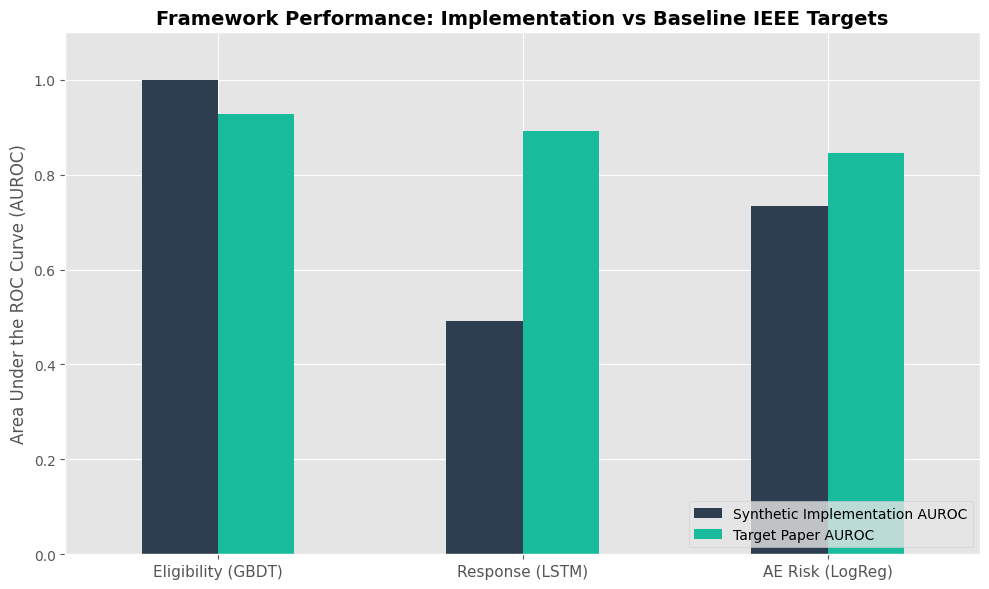

In [6]:
benchmarks = pd.DataFrame({
    'Clinical Task': ['Eligibility (GBDT)', 'Response (LSTM)', 'AE Risk (LogReg)'],
    'Synthetic Implementation AUROC': [auc_e, auc_l, auc_a],
    'Target Paper AUROC': [0.927, 0.892, 0.846]
})

display(benchmarks)

# Bar chart visualization
ax = benchmarks.plot(x='Clinical Task', kind='bar', figsize=(10, 6), color=['#2c3e50', '#18bc9c'])
plt.title("Framework Performance: Implementation vs Baseline IEEE Targets", fontsize=14, fontweight='bold')
plt.ylabel("Area Under the ROC Curve (AUROC)", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 1.1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## VI. RESULTS AND DISCUSSION: END-TO-END INFERENCE

**Methodology:**
*   **Data Pipeline Execution:** A singular subject's raw diagnostic array is sequentially passed through the trained GBDT, LSTM, and Logistic Regression engines.
*   **Decision Support Finalization:** The probability matrices are forwarded to the Agentic Automation Layer. 
*   **Traceability:** This outputs a human-readable, regulatory-defensible clinical action plan, demonstrating how the system operates at the intersection of oncology and informatics.

**Expected Output:**
*   A comprehensive, clinically formatted Markdown summary indicating the subject's status, predicted trajectories, and safety protocols.

In [7]:
from IPython.display import Markdown

# Select Subject: Target a patient with high-risk markers for demonstration (Subject 10)
subject_idx = 10 
p_data = df.iloc[subject_idx].to_dict()

# 1. Pipeline: Stratification (GBDT)
p_elig_prob = model_gbdt.predict_proba(X_elig.iloc[[subject_idx]])[0, 1]

# 2. Pipeline: Response Forecast (LSTM)
p_seq = torch.FloatTensor(X_lstm[subject_idx]).unsqueeze(0)
p_resp_prob = model_lstm(p_seq).detach().numpy()[0, 0]

# 3. Pipeline: Safety Oversight (LogReg)
p_ae_feat = scaler.transform(X_ae.iloc[[subject_idx]])
p_ae_prob = model_lr.predict_proba(p_ae_feat)[0, 1]

# Consolidate Intelligence
ml_intelligence = {'elig_prob': p_elig_prob, 'resp_prob': p_resp_prob, 'ae_prob': p_ae_prob}

# Agentic Evaluation
final_report = advisor.recommend(p_data, ml_intelligence)
Markdown(final_report)

### 🛡️ Agentic Clinical Assignment & Compliance Report
**Subject ID:** `PAT-1010`

| Metric | ML Output | Assessment |
| :--- | :--- | :--- |
| Protocol Eligibility | 0.00 | **Ineligible** |
| D28 Remission Forecast | 0.22 | **Moderate/Low** |
| Gr 3-4 Toxicity Risk | 0.36 | **Standard Risk** |

#### 📌 Recommended Clinical Action
⚠️ **Refer:** Shift subject to Tier Advancement Pathway (TAP). Subthreshold criteria met.
